In [1]:
# Setup
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np
import json
import copy

from utils.data_reader import load_and_prepare_time_series_data
from utils.trainer import Trainer
from models.baseline_models import LSTMModel, BiLSTMModel, GRUModel
from models.custom_models import MGSSMsModel, ExtendedMGSSMsModel

In [2]:
train_loader, val_loader, test_loader, scaler = load_and_prepare_time_series_data(
    filepath_or_url = "https://zenodo.org/records/17109911/files/system_2023.csv",
    target_column=['metropolitan_demand'],
    date_column="time",
    seq_length=14,
    batch_size=64,
    train_split=0.8,
    fill_missing=True)

Fetching data from: https://zenodo.org/records/17109911/files/system_2023.csv
Succesfully loaded 8783 sequential data points.
Prepared:
    --> Training batches: 110
    --> Validation batches: 14
    --> Testing batches: 14


In [3]:
# Setup model configurations
model_config_dict = {
    "Baseline LSTM": LSTMModel(input_size=1, hidden_size=64, num_layers=1, output_size=1),
    "Baseline BiLSTM": BiLSTMModel(input_size=1, hidden_size=64, num_layers=1, output_size=1),
    "Baseline GRU": GRUModel(input_size=1, hidden_size=64, num_layers=1, output_size=1),
    "MGSSMs": MGSSMsModel(input_size=1, hidden_size=64, num_layers=1, output_size=1, gate_size=32),
    "ExtendedMGSSMs": ExtendedMGSSMsModel(input_size=1, hidden_size=48, num_layers=1, output_size=1, gate_size=32, p=2)
}

In [4]:
model_trained = []
for model in model_config_dict.values():
    print(f"Training model: {model.__class__.__name__}")
    trainer = Trainer(
        model=model,
        criterion=nn.MSELoss(),
        optimizer=optim.Adam(model.parameters(), lr=0.001),
        device="cpu"
    )
    train_loader = train_loader
    val_loader = val_loader
    trainer.train(train_loader=train_loader, val_loader=val_loader, epochs=1000, patience=50, label='elec2023')

Training model: LSTMModel
Starting training on device: cpu


Training Model:   0%|          | 0/1000 [00:00<?, ?it/s]

Early stopping triggered after 252 epochs.
Training complete! Best validation loss: 0.0003. Model saved to checkpoints/best_LSTMModel_elec2023.pth
Training model: BiLSTMModel
Starting training on device: cpu


Training Model:   0%|          | 0/1000 [00:00<?, ?it/s]

Early stopping triggered after 370 epochs.
Training complete! Best validation loss: 0.0002. Model saved to checkpoints/best_BiLSTMModel_elec2023.pth
Training model: GRUModel
Starting training on device: cpu


...

Early stopping triggered after 291 epochs.
Training complete! Best validation loss: 0.0002. Model saved to checkpoints/best_GRUModel_elec2023.pth
Training model: MGSSMsModel
Starting training on device: cpu


Training Model:   0%|          | 0/1000 [00:00<?, ?it/s]

Early stopping triggered after 190 epochs.
Training complete! Best validation loss: 0.0007. Model saved to checkpoints/best_MGSSMsModel_elec2023.pth
Training model: ExtendedMGSSMsModel
Starting training on device: cpu


Training Model:   0%|          | 0/1000 [00:00<?, ?it/s]

Early stopping triggered after 305 epochs.
Training complete! Best validation loss: 0.0005. Model saved to checkpoints/best_ExtendedMGSSMsModel_elec2023.pth


In [ ]:
def plot_predictions(model, test_loader, scaler):
    model.eval()
    
    actuals = []
    predictions = []

    with torch.no_grad():
        for batch_x, batch_y in test_loader:
            preds = model(batch_x)
            actuals.extend(batch_y.cpu().numpy().flatten())
            predictions.extend(preds.cpu().numpy().flatten())

    predictions = scaler.inverse_transform(np.array(predictions).reshape(-1, 1))
    actuals = scaler.inverse_transform(np.array(actuals).reshape(-1, 1))
            
    # Plotting the validation data
    plt.figure(figsize=(12, 6))
    plt.plot(actuals, label="Actual metropolitan_demand", color="blue")
    plt.plot(predictions, label="Model Predictions", color="red", linestyle="--")
    plt.title(f"{model.__class__.__name__} Forecasting on COVID-19 Open Data")
    plt.xlabel("hours")
    plt.ylabel("metropolitan_demand")
    plt.xlim(200, 300)
    plt.legend()
    plt.grid(True)
    plt.show()

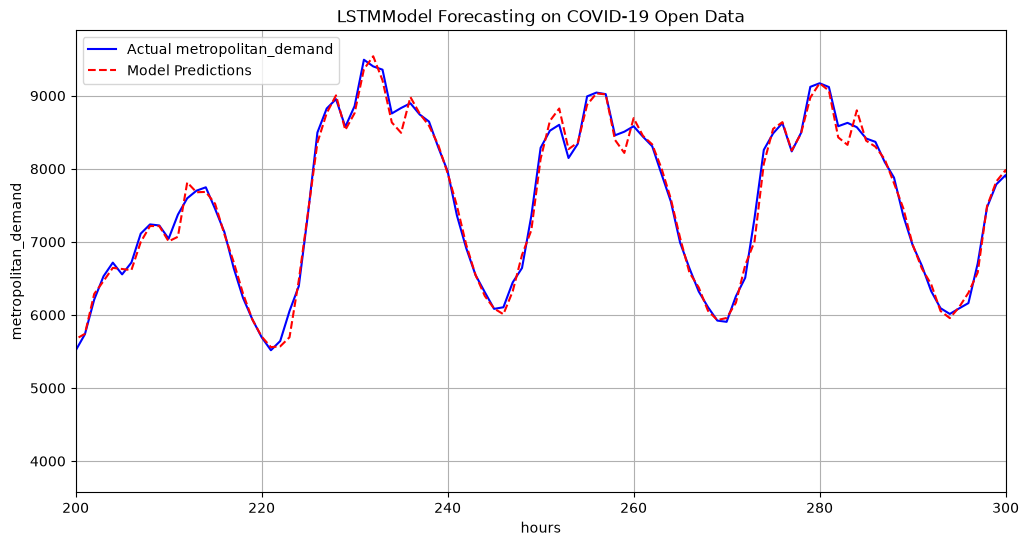

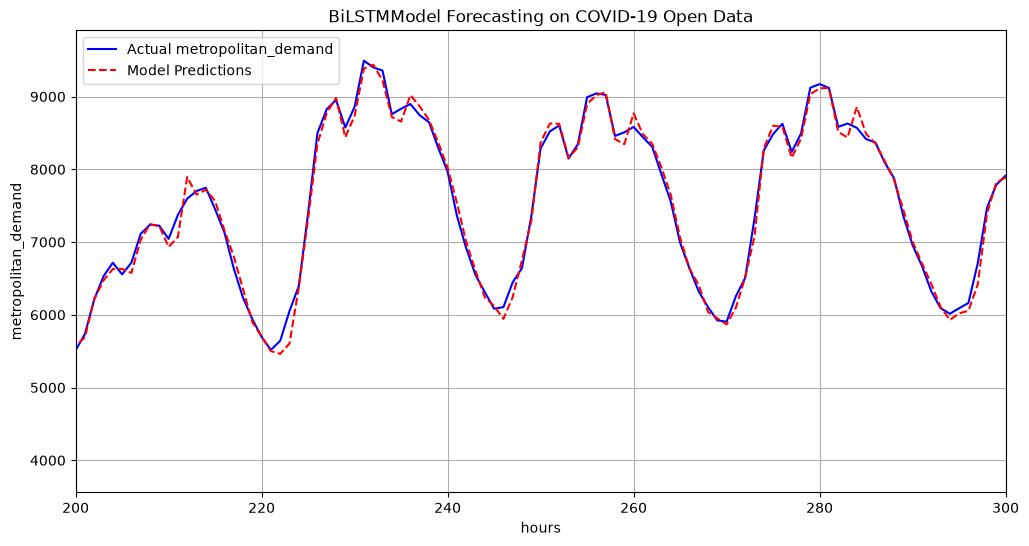

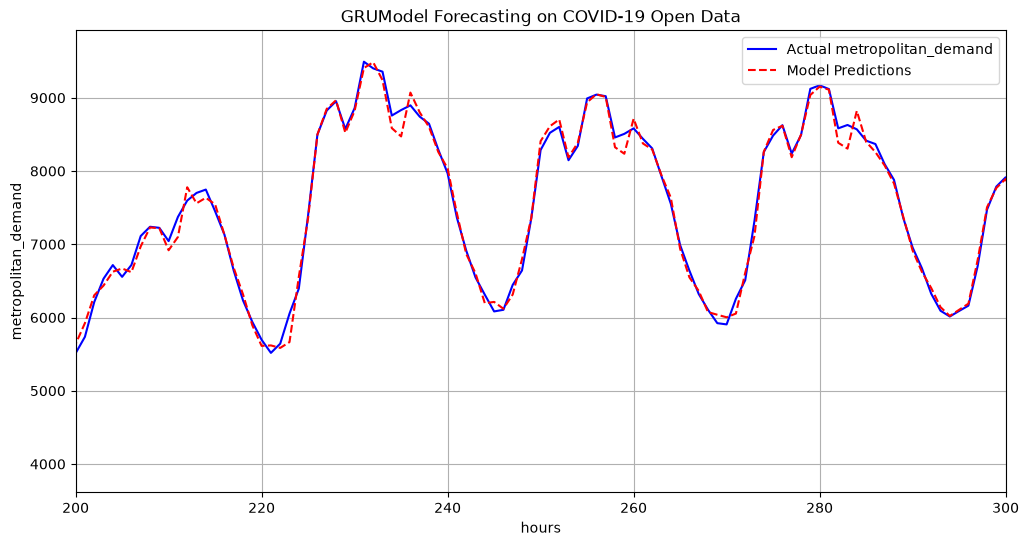

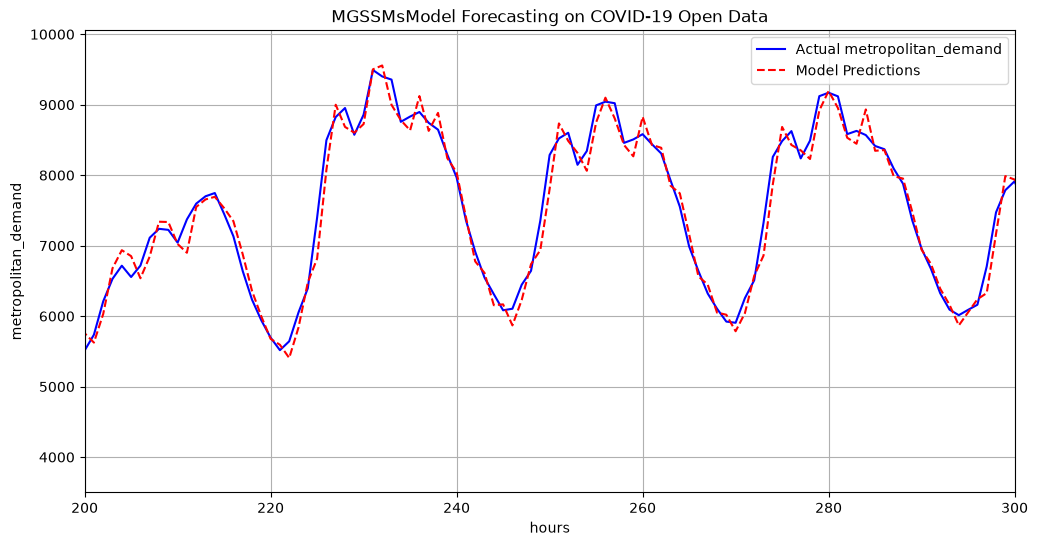

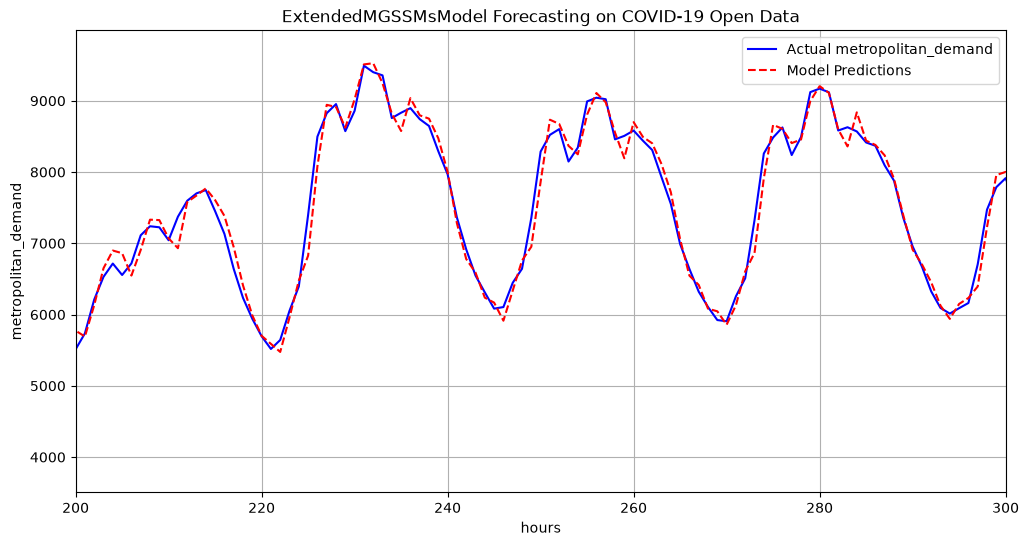

In [10]:
for model_config in model_config_dict.values():
    # analyze the model from the checkpoint
    model_config.load_state_dict(torch.load(f"checkpoints/best_{model_config.__class__.__name__}_elec2023.pth"))
    plot_predictions(model_config, test_loader, scaler)